# Exercise 02 — Karate Club Split

**Topic:** Student 1 — Karate Club Split  
**Dataset:** Zachary's Karate Club graph

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from statistics import mean, median

G = nx.karate_club_graph()

print("Graph loaded successfully")
print("Graph type:", type(G))
print("Is directed:", G.is_directed())

Graph loaded successfully
Graph type: <class 'networkx.classes.graph.Graph'>
Is directed: False


## 2. Check node and edge attributes

The exercise asks us to draw nodes colored by club. The `club` attribute tells us whether a member belongs to the Mr. Hi faction or the Officer faction.

In [ ]:
print("Example node attributes:")
for node, data in list(G.nodes(data=True))[:5]:
    print(node, data)

print("Example edge attributes:")
for u, v, data in list(G.edges(data=True))[:5]:
    print(u, v, data)

Example node attributes:
0 {'club': 'Mr. Hi'}
1 {'club': 'Mr. Hi'}
2 {'club': 'Mr. Hi'}
3 {'club': 'Mr. Hi'}
4 {'club': 'Mr. Hi'}
Example edge attributes:
0 1 {'weight': 4}
0 2 {'weight': 5}
0 3 {'weight': 3}
0 4 {'weight': 3}
0 5 {'weight': 3}


## 3. Basic network metrics

Here we compute the main Lecture 02 metrics: number of nodes, number of edges, density, degree statistics, and connectivity.

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
degree_values = list(degrees.values())

components = list(nx.connected_components(G))

print("Basic metrics")
print("-------------")
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Density: {density:.4f}")
print(f"Minimum degree: {min(degree_values)}")
print(f"Maximum degree: {max(degree_values)}")
print(f"Average degree: {mean(degree_values):.2f}")
print(f"Median degree: {median(degree_values)}")
print(f"Connected components: {len(components)}")
print(f"Largest component size: {len(max(components, key=len))}")

print("Top 5 nodes by degree:")
for node, degree in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"Node {node}: degree {degree}, club = {G.nodes[node]['club']}")

Basic metrics
-------------
Number of nodes: 34
Number of edges: 78
Density: 0.1390
Minimum degree: 1
Maximum degree: 17
Average degree: 4.59
Median degree: 3.0
Connected components: 1
Largest component size: 34
Top 5 nodes by degree:
Node 33: degree 17, club = Officer
Node 0: degree 16, club = Mr. Hi
Node 32: degree 12, club = Officer
Node 2: degree 10, club = Mr. Hi
Node 1: degree 9, club = Mr. Hi


## 4. One shortest path and one cycle

A shortest path shows how two members can be connected through the network. A cycle shows that the graph contains closed relationship structures rather than only tree-like connections.

In [ ]:
source = 0
target = 33

shortest_path = nx.shortest_path(G, source=source, target=target)
shortest_path_length = nx.shortest_path_length(G, source=source, target=target)

print(f"Shortest path from node {source} to node {target}:")
print(" -> ".join(map(str, shortest_path)))
print("Path length:", shortest_path_length)

cycle = nx.find_cycle(G)
print("Example cycle:")
for edge in cycle:
    print(edge)

Shortest path from node 0 to node 33:
0 -> 8 -> 33
Path length: 2
Example cycle:
(0, 1)
(1, 2)
(2, 0)


## 5. Small adjacency-list snippet

This prints a small part of the graph representation, showing the neighbors of the first few nodes.

In [ ]:
print("Adjacency-list snippet:")
for node in list(G.nodes())[:8]:
    neighbors = list(G.neighbors(node))
    print(f"Node {node} ({G.nodes[node]['club']}): {neighbors}")

Adjacency-list snippet:
Node 0 (Mr. Hi): [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Node 1 (Mr. Hi): [0, 2, 3, 7, 13, 17, 19, 21, 30]
Node 2 (Mr. Hi): [0, 1, 3, 7, 8, 9, 13, 27, 28, 32]
Node 3 (Mr. Hi): [0, 1, 2, 7, 12, 13]
Node 4 (Mr. Hi): [0, 6, 10]
Node 5 (Mr. Hi): [0, 6, 10, 16]
Node 6 (Mr. Hi): [0, 4, 5, 16]
Node 7 (Mr. Hi): [0, 1, 2, 3]


## 6. Graph visualization colored by club

Nodes are colored according to the `club` attribute. This helps visually compare the two factions in the network.

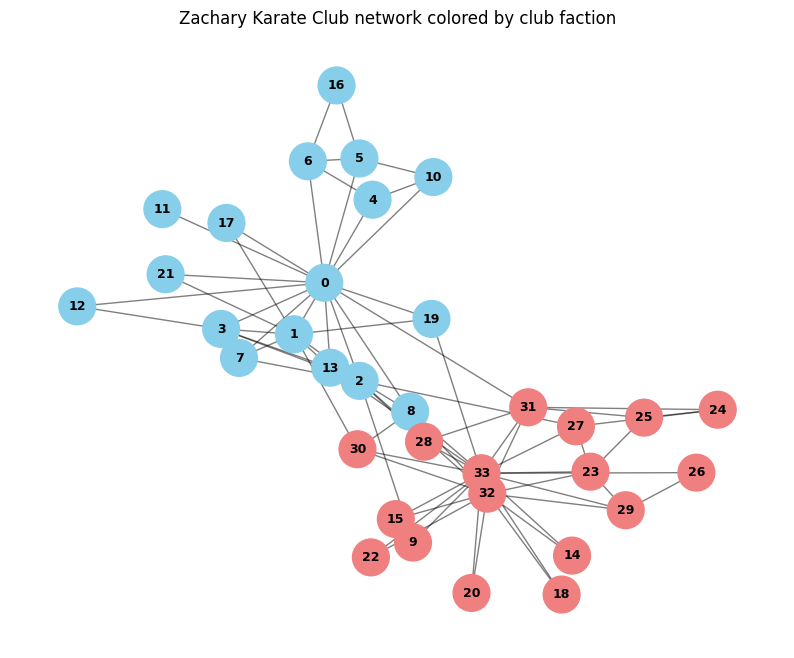

In [ ]:
club_colors = []
for node in G.nodes():
    if G.nodes[node]["club"] == "Mr. Hi":
        club_colors.append("skyblue")
    else:
        club_colors.append("lightcoral")

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_nodes(G, pos, node_color=club_colors, node_size=700)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title("Zachary Karate Club network colored by club faction")
plt.axis("off")
plt.show()

## 7. Short reflection

The Karate Club network is small, with 34 nodes and 78 edges, but it already shows a clear internal structure. The graph is connected, meaning every club member can be reached from every other member through some path. Nodes 0 and 33 have the highest degrees, which suggests that they are important local leaders or central figures in the club. When the graph is colored by the club attribute, many nodes from the same faction appear close together, while only some edges connect the two sides. This suggests that the basic network structure already contains signs of the later split between the two groups.